In [1]:
import numpy as np
import matplotlib.pyplot as plt

from obspy import UTCDateTime
from obspy.clients.fdsn import Client

In [23]:
# User parameters

client = Client("IRISDMC")

stations = ["DUCK1", "DUCK2", "DUCK3"]

network = "UO"
location = "*"
channel = "HNZ"

start = UTCDateTime("2026-09-18T00:22:00")
end = UTCDateTime("2026-09-18T00:24:00")

freqmin = 1.0
freqmax = 10.0

print(f"Start: {start}")
print(f"End:   {end}")
print(f"Stations: {stations}")
print(f"Channel: {channel}")

Start: 2026-09-18T00:22:00.000000Z
End:   2026-09-18T00:24:00.000000Z
Stations: ['DUCK1', 'DUCK2', 'DUCK3']
Channel: HNZ


In [24]:
# Query waveform data

data = {}

for station in stations:
    print(f"Downloading {station}...")

    st = client.get_waveforms(
        network=network,
        station=station,
        location=location,
        channel=channel,
        starttime=start,
        endtime=end
    )

    data[station] = st

    print(st)

1 Trace(s) in Stream:
UO.DUCK1..HNZ | 2026-09-18T00:22:00.000000Z - 2026-09-18T00:24:00.000000Z | 200.0 Hz, 24001 samples
1 Trace(s) in Stream:
UO.DUCK2..HNZ | 2026-09-18T00:22:00.000000Z - 2026-09-18T00:24:00.000000Z | 200.0 Hz, 24001 samples
1 Trace(s) in Stream:
UO.DUCK3..HNZ | 2026-09-18T00:22:00.000000Z - 2026-09-18T00:24:00.000000Z | 200.0 Hz, 24001 samples


In [25]:
# Inspect waveform metadata

for station in stations:
    print(f"\n{station}")

    for tr in data[station]:
        print(
            f"  ID:       {tr.id}\n"
            f"  Start:    {tr.stats.starttime}\n"
            f"  End:      {tr.stats.endtime}\n"
            f"  Samples:  {tr.stats.npts:,}\n"
            f"  Rate:     {tr.stats.sampling_rate} Hz\n"
        )


DUCK1
  ID:       UO.DUCK1..HNZ
  Start:    2026-09-18T00:22:00.000000Z
  End:      2026-09-18T00:24:00.000000Z
  Samples:  24,001
  Rate:     200.0 Hz


DUCK2
  ID:       UO.DUCK2..HNZ
  Start:    2026-09-18T00:22:00.000000Z
  End:      2026-09-18T00:24:00.000000Z
  Samples:  24,001
  Rate:     200.0 Hz


DUCK3
  ID:       UO.DUCK3..HNZ
  Start:    2026-09-18T00:22:00.000000Z
  End:      2026-09-18T00:24:00.000000Z
  Samples:  24,001
  Rate:     200.0 Hz



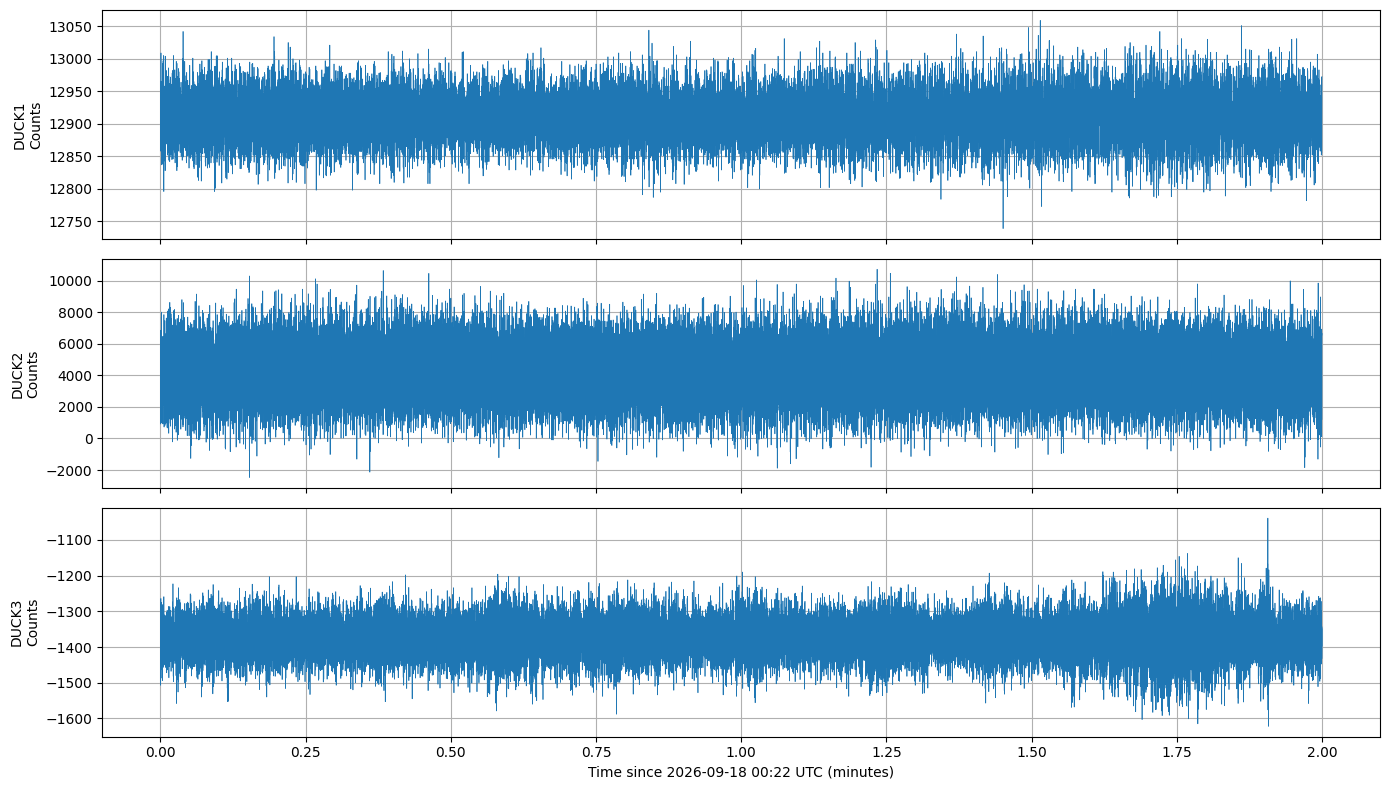

In [26]:
# Plot raw waveforms

fig, axes = plt.subplots(
    len(stations),
    1,
    figsize=(14, 8),
    sharex=True
)

for ax, station in zip(axes, stations):

    tr = data[station][0]
    time = tr.times() / 60.0

    ax.plot(time, tr.data, linewidth=0.5)

    ax.set_ylabel(f"{station}\nCounts")
    ax.grid(True)

axes[-1].set_xlabel(
    f"Time since {start.strftime('%Y-%m-%d %H:%M')} UTC (minutes)"
)

plt.tight_layout()
plt.show()

In [27]:
# Get instrument responses and create processed streams

inventory = {}
processed = {}

for station in stations:

    inventory[station] = client.get_stations(
        network=network,
        station=station,
        location=location,
        channel=channel,
        starttime=start,
        endtime=end,
        level="response"
    )

    processed[station] = data[station].copy()

    print(f"{station}: response metadata downloaded")

# Remove the instrument response and convert the data to ground velocity.

for station in stations:

    processed[station].remove_response(
        inventory=inventory[station],
        output="VEL"
    )

    print(f"{station}: instrument response removed")

DUCK1: response metadata downloaded
DUCK2: response metadata downloaded
DUCK3: response metadata downloaded
DUCK1: instrument response removed
DUCK2: instrument response removed
DUCK3: instrument response removed


In [28]:
# Remove the mean and linear trend from each waveform.

for station in stations:

    processed[station].detrend("demean")
    processed[station].detrend("linear")

print("Detrending complete.")

Detrending complete.


In [29]:
# Apply bandpass filter

pre_filt = [0.5*freqmin, 0.8*freqmin, 1.2*freqmax, 1.5*freqmax]

for station in stations:

    processed[station].remove_response(
        inventory=inventory[station],
        output="VEL",
        pre_filt=pre_filt
    )

    processed[station].detrend("demean")
    processed[station].detrend("linear")

    processed[station].filter(
        "bandpass",
        freqmin=freqmin,
        freqmax=freqmax,
        corners=4,
        zerophase=True
    )

print(f"Applied {freqmin}–{freqmax} Hz bandpass filter.")

Applied 1.0–10.0 Hz bandpass filter.


In [30]:
# Compare processed amplitudes

for station in stations:

    tr = processed[station][0]

    rms = np.sqrt(np.mean(tr.data**2))
    maximum = np.max(np.abs(tr.data))

    print(
        f"{station}: "
        f"RMS = {rms:.3e}, "
        f"max = {maximum:.3e}"
    )

DUCK1: RMS = 2.800e-13, max = 1.334e-12
DUCK2: RMS = 3.539e-13, max = 1.977e-12
DUCK3: RMS = 1.568e-13, max = 7.115e-13


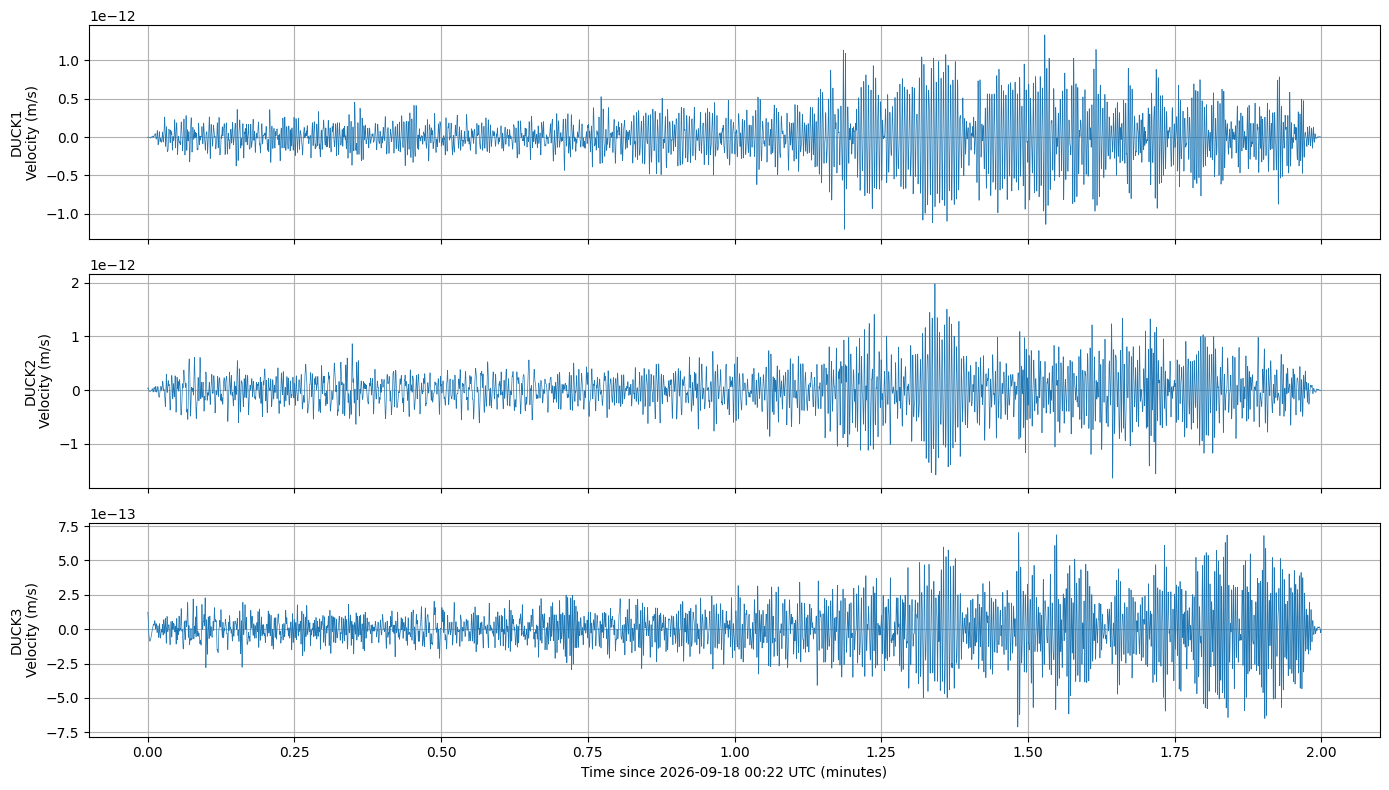

In [31]:
fig, axes = plt.subplots(
    len(stations),
    1,
    figsize=(14, 8),
    sharex=True
)

for ax, station in zip(axes, stations):

    tr = processed[station][0]
    time = tr.times() / 60.0

    ax.plot(time, tr.data, linewidth=0.5)

    ax.set_ylabel(f"{station}\nVelocity (m/s)")
    ax.grid(True)

axes[-1].set_xlabel(
    f"Time since {start.strftime('%Y-%m-%d %H:%M')} UTC (minutes)"
)

plt.tight_layout()
plt.show()

In [32]:
# Get station coordinates

station_inventory = client.get_stations(
    network=network,
    station=",".join(stations),
    location=location,
    channel=channel,
    starttime=start,
    endtime=end,
    level="station"
)

station_coords = {}

for network_obj in station_inventory:
    for station_obj in network_obj.stations:

        station_coords[station_obj.code] = (
            station_obj.latitude,
            station_obj.longitude
        )

        print(
            station_obj.code,
            station_obj.latitude,
            station_obj.longitude
        )

DUCK1 44.0574 -123.06877
DUCK2 44.057738 -123.069144
DUCK3 44.05901 -123.06825


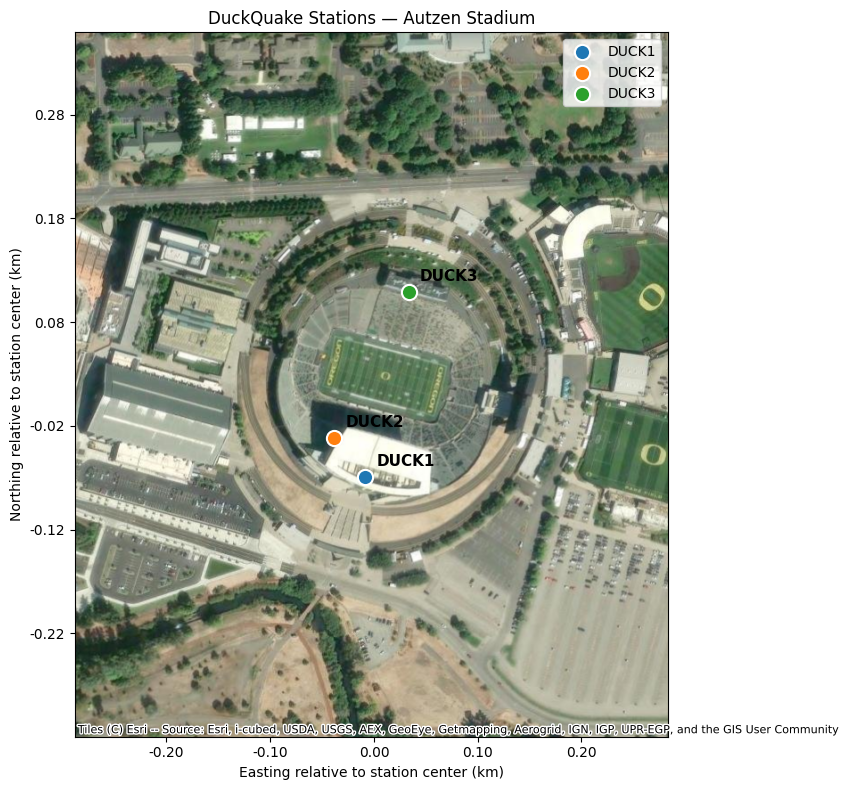

In [33]:
import contextily as ctx
import matplotlib.pyplot as plt
from pyproj import Transformer
from matplotlib.ticker import FuncFormatter

# WGS84 lat/lon -> UTM Zone 10N
transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:32610",
    always_xy=True
)

# Convert station coordinates to UTM
station_utm = {}

for station, (lat, lon) in station_coords.items():
    x, y = transformer.transform(lon, lat)
    station_utm[station] = (x, y)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

for station, (x, y) in station_utm.items():
    ax.scatter(
        x, y,
        s=120,
        edgecolor="white",
        linewidth=1.5,
        zorder=5,
        label=station
    )

    ax.annotate(
        station,
        (x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
        zorder=6
    )

# Zoom out slightly
xs = [x for x, y in station_utm.values()]
ys = [y for x, y in station_utm.values()]

pad = 250  # meters

ax.set_xlim(min(xs) - pad, max(xs) + pad)
ax.set_ylim(min(ys) - pad, max(ys) + pad)

# Satellite imagery
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery,
    crs="EPSG:32610"
)

# Format coordinates in km relative to approximate stadium center
stadium_x = sum(xs) / len(xs)
stadium_y = sum(ys) / len(ys)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{(x - stadium_x)/1000:.2f}")
)
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f"{(y - stadium_y)/1000:.2f}")
)

ax.set_xlabel("Easting relative to station center (km)")
ax.set_ylabel("Northing relative to station center (km)")
ax.set_title("DuckQuake Stations — Autzen Stadium")

ax.legend(loc="upper right")

ax.set_aspect("equal")

plt.tight_layout()
plt.show()

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import contextily as ctx

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

stations = ["DUCK1", "DUCK2", "DUCK3"]

frame_dt = 0.20
window_length = 30.0

# RMS window
rms_window = 5.0

# Automatically match FPS to frame interval
fps = int(round(1.0 / frame_dt))

# Minimum and maximum dot size
min_marker_size = 80
max_marker_size = 1200

# ------------------------------------------------------------
# Get traces
# ------------------------------------------------------------

traces = {
    station: processed[station][0]
    for station in stations
}

# Common time range
common_start = max(
    tr.stats.starttime for tr in traces.values()
)

common_end = min(
    tr.stats.endtime for tr in traces.values()
)

duration = common_end - common_start

# Start animation only after a full waveform history exists
times = np.arange(
    window_length,
    duration - rms_window,
    frame_dt
)

print(f"Animation starts at: {window_length} s")
print(f"Frame interval: {frame_dt} s")
print(f"Movie FPS: {fps}")
print(f"Number of frames: {len(times)}")

# ------------------------------------------------------------
# Calculate RMS amplitude for EVERY frame
# ------------------------------------------------------------

rms_amplitudes = {
    station: np.zeros(len(times))
    for station in stations
}

for station in stations:

    tr = traces[station]

    for i, t in enumerate(times):

        # RMS window begins at current time
        t0 = common_start + t
        t1 = t0 + rms_window

        segment = tr.slice(
            starttime=t0,
            endtime=t1
        ).data

        if len(segment) > 0:

            rms_amplitudes[station][i] = np.sqrt(
                np.mean(segment ** 2)
            )

# ------------------------------------------------------------
# Automatically determine amplitude scaling
# ------------------------------------------------------------

all_rms = np.concatenate([
    rms_amplitudes[station]
    for station in stations
])

# Ignore zero values
all_rms = all_rms[all_rms > 0]

# Use percentiles so one giant spike doesn't dominate
amp_min = np.percentile(
    all_rms,
    5
)

amp_max = np.percentile(
    all_rms,
    99
)

print("RMS amplitude range:")
print(f"  5th percentile:  {amp_min:.3e}")
print(f"  99th percentile: {amp_max:.3e}")

# ------------------------------------------------------------
# Determine ONE common waveform y-scale
# ------------------------------------------------------------

all_waveform_data = np.concatenate([
    traces[station].data
    for station in stations
])

common_yscale = np.percentile(
    np.abs(all_waveform_data),
    99
)

# Add a little headroom
common_yscale *= 1.1

print(
    f"Common waveform y-scale: ±{common_yscale:.3e}"
)

# ------------------------------------------------------------
# Station coordinates
# ------------------------------------------------------------

xs = np.array([
    station_utm[s][0]
    for s in stations
])

ys = np.array([
    station_utm[s][1]
    for s in stations
])

pad = 250

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(12, 10)
)

# ------------------------------------------------------------
# Map
# ------------------------------------------------------------

ax_map = fig.add_axes(
    [0.08, 0.48, 0.84, 0.45]
)

ax_map.set_xlim(
    xs.min() - pad,
    xs.max() + pad
)

ax_map.set_ylim(
    ys.min() - pad,
    ys.max() + pad
)

ctx.add_basemap(
    ax_map,
    source=ctx.providers.Esri.WorldImagery,
    crs="EPSG:32610"
)

# Initial station dots
scatter = ax_map.scatter(
    xs,
    ys,
    s=np.ones(3) * min_marker_size,
    edgecolor="white",
    linewidth=2,
    zorder=5
)

# Station labels
for station, x, y in zip(
    stations,
    xs,
    ys
):

    ax_map.annotate(
        station,
        (x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=12,
        fontweight="bold",
        color="white",
        zorder=6
    )

time_text = ax_map.text(
    0.02,
    0.95,
    "",
    transform=ax_map.transAxes,
    fontsize=14,
    fontweight="bold",
    color="white",
    bbox=dict(
        facecolor="black",
        alpha=0.6,
        edgecolor="none"
    )
)

ax_map.set_title(
    "DuckQuake — Autzen Stadium"
)

ax_map.set_xlabel(
    "Easting (m)"
)

ax_map.set_ylabel(
    "Northing (m)"
)

ax_map.set_aspect(
    "equal"
)

# ------------------------------------------------------------
# Waveform panels
# ------------------------------------------------------------

wave_axes = []

# More vertical space between waveform panels
wave_y_positions = [
    0.315,
    0.195,
    0.075
]

wave_height = 0.085

for station, y in zip(
    stations,
    wave_y_positions
):

    ax = fig.add_axes(
        [
            0.08,
            y,
            0.84,
            wave_height
        ]
    )

    wave_axes.append(ax)

    # SAME y-scale for every station
    ax.set_ylim(
        -common_yscale,
        common_yscale
    )

    # Station label INSIDE waveform
    ax.text(
        0.01,
        0.82,
        station,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        color="black",
        zorder=10
    )

    ax.grid(
        alpha=0.3
    )

# ------------------------------------------------------------
# Animation
# ------------------------------------------------------------

def update(frame):

    t = times[frame]

    # ----------------------------------------
    # Get RMS amplitudes
    # ----------------------------------------

    amplitudes = np.array([
        rms_amplitudes[station][frame]
        for station in stations
    ])

    # ----------------------------------------
    # Normalize amplitudes automatically
    # ----------------------------------------

    normalized = (
        amplitudes - amp_min
    ) / (
        amp_max - amp_min
    )

    normalized = np.clip(
        normalized,
        0,
        1
    )

    # Convert to marker sizes
    sizes = (
        min_marker_size
        + normalized
        * (
            max_marker_size
            - min_marker_size
        )
    )

    scatter.set_sizes(
        sizes
    )

    # ----------------------------------------
    # Scrolling seismograms
    # ----------------------------------------

    window_start = (
        t - window_length
    )

    window_end = (
        t + rms_window
    )

    for i, (ax, station) in enumerate(
        zip(
            wave_axes,
            stations
        )
    ):

        tr = traces[station]

        starttime = (
            common_start
            + window_start
        )

        endtime = (
            common_start
            + window_end
        )

        segment = tr.slice(
            starttime=starttime,
            endtime=endtime
        )

        # Clear old waveform
        ax.clear()

        if len(segment) > 0:

            waveform_time = (
                segment.times()
                + (
                    segment.stats.starttime
                    - common_start
                )
            )

            ax.plot(
                waveform_time,
                segment.data,
                linewidth=0.7,
                zorder=2
            )

        # ------------------------------------
        # SAME y-scale for every station
        # ------------------------------------

        ax.set_ylim(
            -common_yscale,
            common_yscale
        )

        ax.set_xlim(
            window_start,
            window_end
        )

        # ------------------------------------
        # Station label INSIDE plot
        # ------------------------------------

        ax.text(
            0.01,
            0.82,
            station,
            transform=ax.transAxes,
            fontsize=11,
            fontweight="bold",
            color="black",
            zorder=10
        )

        ax.grid(
            alpha=0.3
        )

        # ------------------------------------
        # RMS shaded window
        # ------------------------------------

        ax.axvspan(
            t,
            t + rms_window,

            facecolor="red",
            alpha=0.18,

            edgecolor="none",
            linewidth=0,

            zorder=1
        )

        # ------------------------------------
        # Positive RMS horizontal line
        # ------------------------------------

        rms = rms_amplitudes[
            station
        ][frame]

        ax.plot(
            [t, t + rms_window],
            [rms, rms],

            color="red",
            linewidth=2.0,

            zorder=4
        )

    # ----------------------------------------
    # Time display
    # ----------------------------------------

    time_text.set_text(
        f"{t:.0f} s"
    )

    return (
        scatter,
        time_text
    )


# ------------------------------------------------------------
# Create animation
# ------------------------------------------------------------

ani = FuncAnimation(
    fig,
    update,
    frames=len(times),
    interval=frame_dt * 1000,
    blit=False
)

# FPS automatically matches frame_dt
writer = FFMpegWriter(
    fps=fps,
    bitrate=3000
)

print(f"Saving at {fps} FPS...")

ani.save(
    "duckquake_station_amplitudes.mp4",
    writer=writer,
    dpi=120
)

plt.close()

print(
    "Saved: duckquake_station_amplitudes.mp4"
)

Animation starts at: 30.0 s
Frame interval: 0.2 s
Movie FPS: 5
Number of frames: 425
RMS amplitude range:
  5th percentile:  9.226e-14
  99th percentile: 7.306e-13
Common waveform y-scale: ±1.031e-12
Saving at 5 FPS...
Saved: duckquake_station_amplitudes.mp4
